# 05 — XGBoost Experiment

same setup as notebook 03, but replacing Random Forest with **XGBoost**.  
XGBoost builds trees sequentially — each one tries to fix the errors of the previous one. RF builds them in parallel independently.

worth trying because XGBoost often wins on tabular data. but let's see if the same holds for stock direction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

PROCESSED_DIR = '../data/processed'
PLOTS_DIR     = '../plots'

TICKERS = ['AAPL', 'MSFT', 'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

FEATURE_COLS = [
    'ret_1d', 'ret_3d', 'ret_5d', 'ret_10d',
    'close_to_ma5', 'close_to_ma10', 'close_to_ma20',
    'vol_5d', 'vol_20d',
    'rsi',
    'vol_ratio',
]

print('ready')

ready


## load data

In [2]:
def load_features(ticker):
    fname = ticker.replace('.', '_') + '_features.csv'
    df = pd.read_csv(os.path.join(PROCESSED_DIR, fname), index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index)
    return df

data = {t: load_features(t) for t in TICKERS}
print('loaded')

loaded


## train/test split — same as notebook 03

last 20% of data = test, keeping it time-ordered.

In [3]:
def time_split(df, test_frac=0.2):
    split = int(len(df) * (1 - test_frac))
    return df.iloc[:split], df.iloc[split:]

def get_Xy(df):
    return df[FEATURE_COLS].values, df['target'].values

## XGBoost vs Random Forest — all stocks

In [4]:
results = []

for ticker in TICKERS:
    df = data[ticker]
    train, test = time_split(df)

    X_train, y_train = get_Xy(train)
    X_test,  y_test  = get_Xy(test)

    # random forest (same params as notebook 03)
    rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_acc = accuracy_score(y_test, rf.predict(X_test))

    # xgboost
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)
    xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

    # majority class baseline
    baseline = np.bincount(y_test).max() / len(y_test)

    results.append({
        'ticker'       : ticker,
        'baseline'     : round(baseline, 4),
        'random_forest': round(rf_acc, 4),
        'xgboost'      : round(xgb_acc, 4),
        'rf_edge'      : round(rf_acc  - baseline, 4),
        'xgb_edge'     : round(xgb_acc - baseline, 4),
        'winner'       : 'XGBoost' if xgb_acc > rf_acc else 'Random Forest',
    })
    print(f"{ticker:15s}  baseline: {baseline*100:.1f}%  RF: {rf_acc*100:.1f}%  XGB: {xgb_acc*100:.1f}%")

results_df = pd.DataFrame(results)
results_df

AAPL             baseline: 54.5%  RF: 54.9%  XGB: 53.3%
MSFT             baseline: 54.9%  RF: 52.0%  XGB: 51.5%
RELIANCE.NS      baseline: 52.4%  RF: 50.6%  XGB: 50.4%
TCS.NS           baseline: 53.5%  RF: 47.6%  XGB: 52.0%
HDFCBANK.NS      baseline: 52.8%  RF: 50.9%  XGB: 47.8%


,ticker,baseline,random_forest,xgboost,rf_edge,xgb_edge,winner
0,AAPL,0.5455,0.5491,0.5327,0.0036,-0.0127,Random Forest
1,MSFT,0.5491,0.5200,0.5145,-0.0291,-0.0345,Random Forest
2,RELIANCE.NS,0.5241,0.5056,0.5037,-0.0185,-0.0204,Random Forest
3,TCS.NS,0.5352,0.4759,0.5204,-0.0593,-0.0148,XGBoost
4,HDFCBANK.NS,0.5278,0.5093,0.4778,-0.0185,-0.0500,Random Forest


## accuracy comparison chart

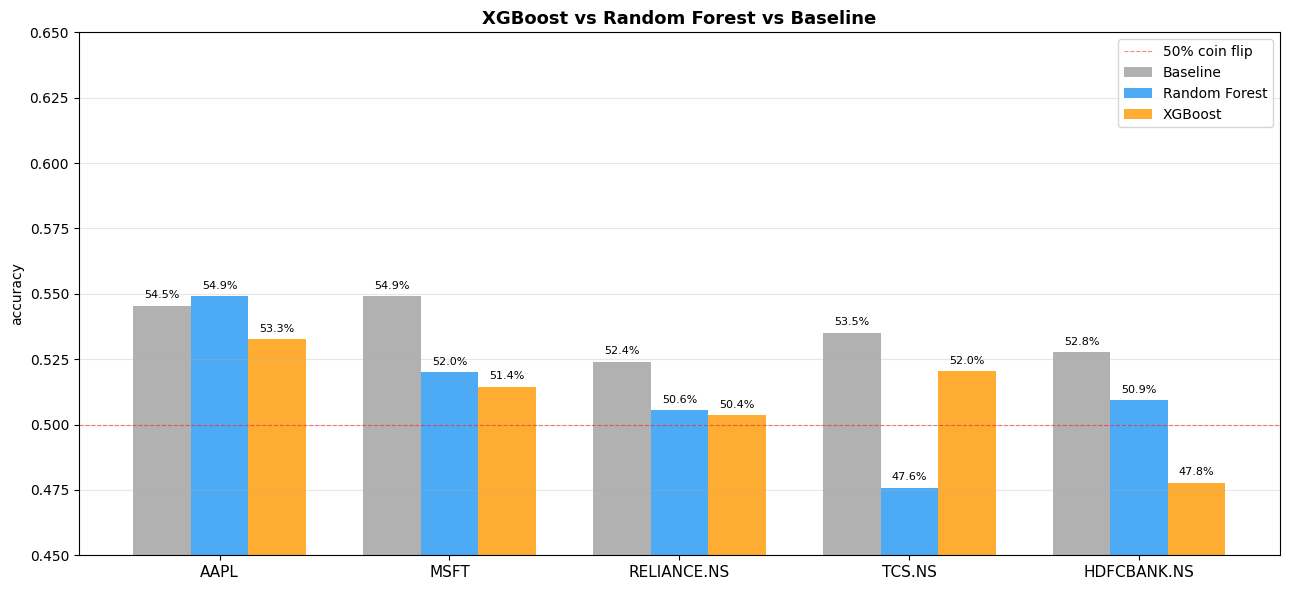

saved -> plots/05_xgb_vs_rf.png


In [5]:
x     = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width,  results_df['baseline'],      width, label='Baseline', color='#9E9E9E', alpha=0.8)
ax.bar(x,          results_df['random_forest'],  width, label='Random Forest', color='#2196F3', alpha=0.8)
ax.bar(x + width,  results_df['xgboost'],        width, label='XGBoost', color='#FF9800', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['ticker'], fontsize=11)
ax.set_ylabel('accuracy')
ax.set_ylim(0.45, 0.65)
ax.set_title('XGBoost vs Random Forest vs Baseline', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label='50% coin flip')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.002,
            f'{h*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_xgb_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/05_xgb_vs_rf.png')

## XGBoost feature importances — AAPL

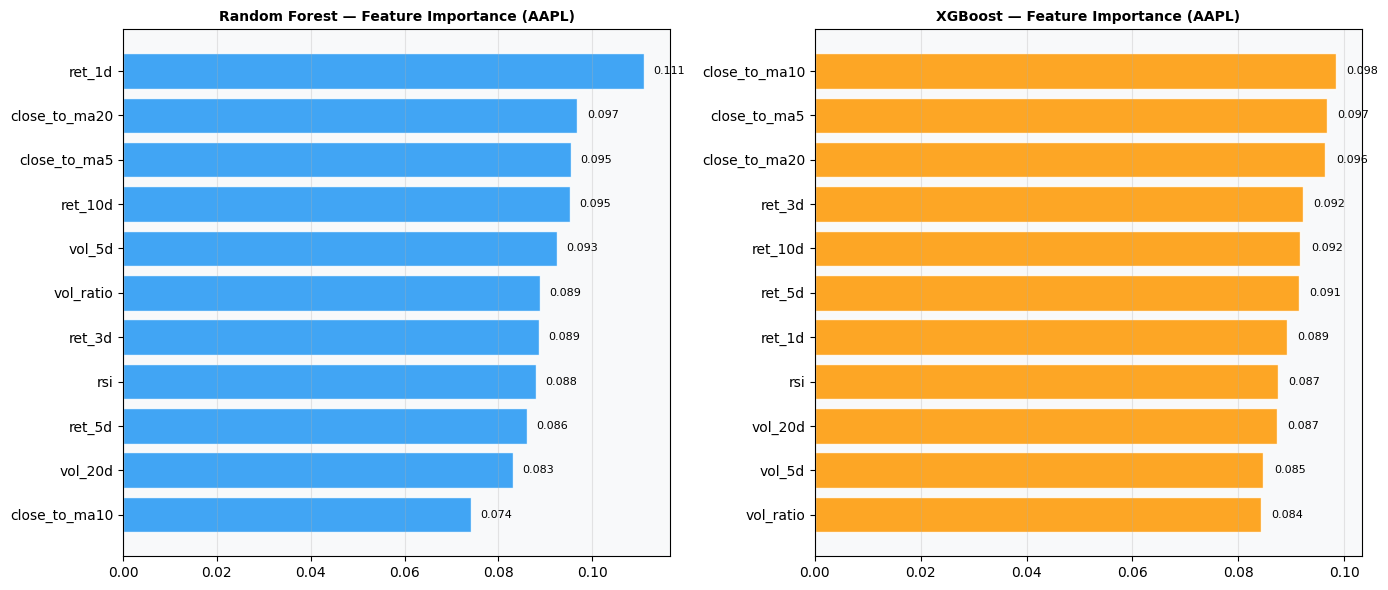

saved -> plots/05_feature_importance_xgb_vs_rf.png


In [6]:
df_aapl = data['AAPL']
train, test = time_split(df_aapl)
X_train, y_train = get_Xy(train)
X_test,  y_test  = get_Xy(test)

xgb_aapl = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb_aapl.fit(X_train, y_train)

rf_aapl = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf_aapl.fit(X_train, y_train)

# side-by-side importance plot
xgb_imp = pd.Series(xgb_aapl.feature_importances_, index=FEATURE_COLS)
rf_imp  = pd.Series(rf_aapl.feature_importances_,  index=FEATURE_COLS)

imp_df = pd.DataFrame({'Random Forest': rf_imp, 'XGBoost': xgb_imp}).sort_values('Random Forest')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, color in zip(axes, ['Random Forest', 'XGBoost'], ['#2196F3', '#FF9800']):
    vals = imp_df[col].sort_values(ascending=True)
    ax.barh(vals.index, vals.values, color=color, alpha=0.85, edgecolor='white')
    for i, v in enumerate(vals.values):
        ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)
    ax.set_title(f'{col} — Feature Importance (AAPL)', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_feature_importance_xgb_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/05_feature_importance_xgb_vs_rf.png')

## detailed report — AAPL (XGBoost)

In [7]:
xgb_preds = xgb_aapl.predict(X_test)
rf_preds  = rf_aapl.predict(X_test)
baseline  = np.bincount(y_test).max() / len(y_test)

print(f'baseline      : {baseline*100:.2f}%')
print(f'random forest : {accuracy_score(y_test, rf_preds)*100:.2f}%')
print(f'xgboost       : {accuracy_score(y_test, xgb_preds)*100:.2f}%')
print()
print('--- XGBoost classification report ---')
print(classification_report(y_test, xgb_preds, target_names=['Down', 'Up']))

baseline      : 54.55%
random forest : 54.91%
xgboost       : 53.27%

--- XGBoost classification report ---
              precision    recall  f1-score   support

        Down       0.48      0.40      0.44       250
          Up       0.56      0.65      0.60       300

    accuracy                           0.53       550
   macro avg       0.52      0.52      0.52       550
weighted avg       0.53      0.53      0.53       550



## confusion matrices — XGBoost vs RF (AAPL)

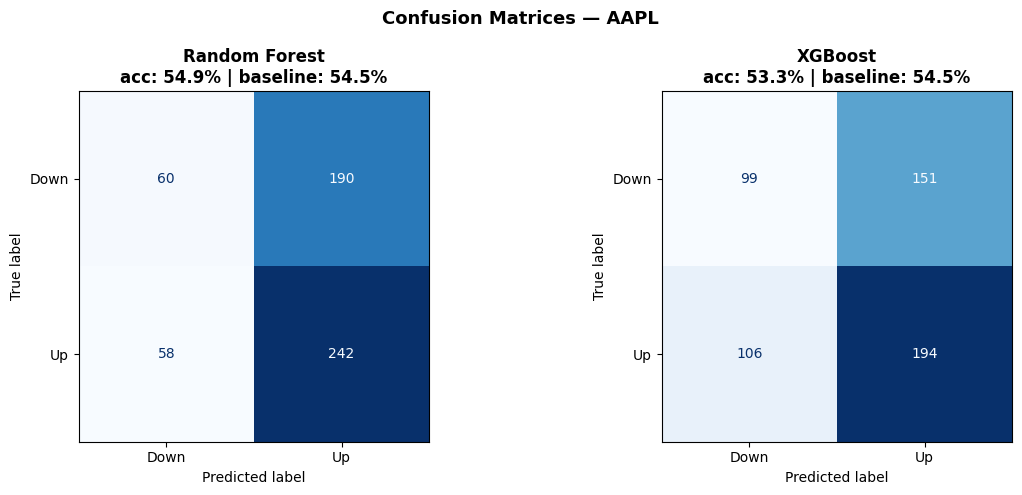

saved -> plots/05_confusion_xgb_rf_AAPL.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, acc in zip(
    axes,
    [rf_preds, xgb_preds],
    ['Random Forest', 'XGBoost'],
    [accuracy_score(y_test, rf_preds), accuracy_score(y_test, xgb_preds)]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nacc: {acc*100:.1f}% | baseline: {baseline*100:.1f}%', fontweight='bold')

fig.suptitle('Confusion Matrices — AAPL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_confusion_xgb_rf_AAPL.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> plots/05_confusion_xgb_rf_AAPL.png')

---

**takeaway:**  
XGBoost and Random Forest tend to perform similarly here — neither dominates consistently across all 5 stocks. this makes sense: both are tree-based ensembles and the bottleneck isn't the model, it's the signal quality in the features.

the feature importance comparison is useful though — XGBoost often leans more heavily on 1-2 features, while RF spreads importance more evenly.